# Mortgage Loan Limit Prediction — Exploratory Data Analysis

## Project Overview

This capstone project develops a machine learning model to predict a borrower's maximum mortgage loan amount using demographic, financial, credit, and loan-history information.

The project is structured in three notebooks:

1. **Exploratory Data Analysis**
2. **Regression Modeling and Model Evaluation**
3. **Interest-Rate Forecasting and 10-Year Borrowing Capacity Projection**

This first notebook focuses on understanding the mortgage loan dataset, identifying useful features, visualizing relationships, and preparing an engineered dataset for modeling.

## Business Understanding

Mortgage lenders and borrowers both need to understand what factors influence maximum loan amount. A loan amount that is too high may increase default risk, while a loan amount that is too low may reduce borrower satisfaction and lending opportunity. This analysis investigates how variables such as income, down payment, credit score, interest rate, employment history, existing debt, and demographic information relate to maximum mortgage borrowing capacity.

## Research Question

The main research question for this project is:

> Can borrower demographic, financial, credit, and loan-history features be used to predict maximum mortgage loan amount?

In [1]:
#Set_Up
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
#File_paths_Definition
DATA_PATH = Path("mortgage_loan_dataset.csv")
OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
PROCESSED_DIR = OUTPUT_DIR / "processed_data"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print("Current working directory:")
print(os.getcwd())
print("\nExpected data file:")
print(DATA_PATH.resolve())

Current working directory:
/Users/ziyang/anaconda_projects/Berkeley ML_AI Learning/Module 24/example

Expected data file:
/Users/ziyang/anaconda_projects/Berkeley ML_AI Learning/Module 24/example/mortgage_loan_dataset.csv


In [3]:
# Dataset_Loading
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")
df.head()

Dataset loaded successfully.
Number of rows: 49,990
Number of columns: 14


,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
0,Male,36,Yes,PhD,Software Engineer,13,"134,183.86",0.08,"101,706.78",682,"2,045.80",Urban,3,"498,842.67"
1,Female,63,No,High School,Freelancer,37,"68,884.95",0.03,"46,324.29",823,804.73,Suburban,10,"536,232.53"
2,Female,33,Yes,PhD,Nurse,11,"76,396.27",0.03,"13,045.79",813,"1,050.54",Urban,0,"518,884.47"
3,Female,51,Yes,Bachelor's,Business Owner,29,"115,968.80",0.05,"60,388.40",752,904.08,Rural,2,"757,940.14"
4,Male,53,Yes,Bachelor's,Nurse,27,"99,977.38",0.06,"54,838.14",728,"2,285.76",Rural,1,"283,110.21"


In [4]:
df.columns.tolist()

['Gender',
 'Age',
 'Married',
 'Education',
 'Job',
 'Employment Years',
 'Annual Income (USD)',
 'Interest Rate',
 'Down Payment (USD)',
 'Credit Score',
 'Existing Monthly Debt (USD)',
 'Area',
 'Loans Repaid',
 'Max Loan Amount (USD)']

## Data Dictionary

From the initial screening, the dataset contains borrower demographic, financial, credit, and loan-history information.

The target variable is:

- **Max Loan Amount (USD)**: the maximum mortgage loan amount associated with the borrower profile.

Input features include:

- Gender
- Age
- Married
- Education
- Job
- Employment Years
- Annual Income
- Interest Rate
- Down Payment
- Credit Score
- Existing Monthly Debt
- Area
- Loans Repaid

In [5]:
# Dataset_basic_info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49990 entries, 0 to 49989
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       49990 non-null  object 
 1   Age                          49990 non-null  int64  
 2   Married                      49990 non-null  object 
 3   Education                    49990 non-null  object 
 4   Job                          49990 non-null  object 
 5   Employment Years             49990 non-null  int64  
 6   Annual Income (USD)          49990 non-null  float64
 7   Interest Rate                49990 non-null  float64
 8   Down Payment (USD)           49990 non-null  float64
 9   Credit Score                 49990 non-null  int64  
 10  Existing Monthly Debt (USD)  49990 non-null  float64
 11  Area                         49990 non-null  object 
 12  Loans Repaid                 49990 non-null  int64  
 13  Max Loan Amount 

In [6]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"49,990.00",57.05,16.95,28.00,42.00,57.00,72.00,86.00
Employment Years,"49,990.00",32.07,15.17,0.00,19.00,34.00,48.00,50.00
Annual Income (USD),"49,990.00","120,323.42","36,965.12","25,000.00","95,011.17","119,978.23","145,455.79","274,740.32"
Interest Rate,"49,990.00",0.05,0.02,0.03,0.03,0.05,0.06,0.12
Down Payment (USD),"49,990.00","64,296.94","39,594.86","5,000.00","34,152.76","59,097.87","87,905.06","250,000.00"
Credit Score,"49,990.00",760.37,63.39,580.00,717.00,764.00,811.00,850.00
Existing Monthly Debt (USD),"49,990.00","1,656.60",751.03,0.00,"1,099.92","1,564.65","2,140.26","5,000.00"
Loans Repaid,"49,990.00",5.83,3.43,0.00,3.00,5.00,8.00,24.00
Max Loan Amount (USD),"49,990.00","663,419.15","312,681.14","26,142.54","425,422.80","623,243.47","864,104.89","2,270,835.80"


In [7]:
# Summary for categorical columns
df.describe(include="object").T

,count,unique,top,freq
Gender,49990,2,Female,25938
Married,49990,2,Yes,30763
Education,49990,4,Bachelor's,19920
Job,49990,12,Business Owner,4235
Area,49990,3,Urban,27466


In [8]:
# Check missing values
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})
missing_values_df

,Missing Values,Missing Percentage
Gender,0,0.00
Age,0,0.00
Married,0,0.00
Education,0,0.00
Job,0,0.00
Employment Years,0,0.00
Annual Income (USD),0,0.00
Interest Rate,0,0.00
Down Payment (USD),0,0.00
Credit Score,0,0.00


In [9]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Number of duplicated rows: 0
Duplicate percentage: 0.00%


In [10]:
# Separate numerical and categorical columns
target = "Max Loan Amount (USD)"
categorical_columns = df.select_dtypes(include="object").columns.tolist()
numerical_columns = df.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Gender', 'Married', 'Education', 'Job', 'Area']

Numerical columns:
['Age', 'Employment Years', 'Annual Income (USD)', 'Interest Rate', 'Down Payment (USD)', 'Credit Score', 'Existing Monthly Debt (USD)', 'Loans Repaid', 'Max Loan Amount (USD)']


## Target Variable Analysis

The target variable is **Max Loan Amount (USD)**.

The following activities are screening to identify skewness, outliers, and the general scale of prediction errors expected in the regression task.

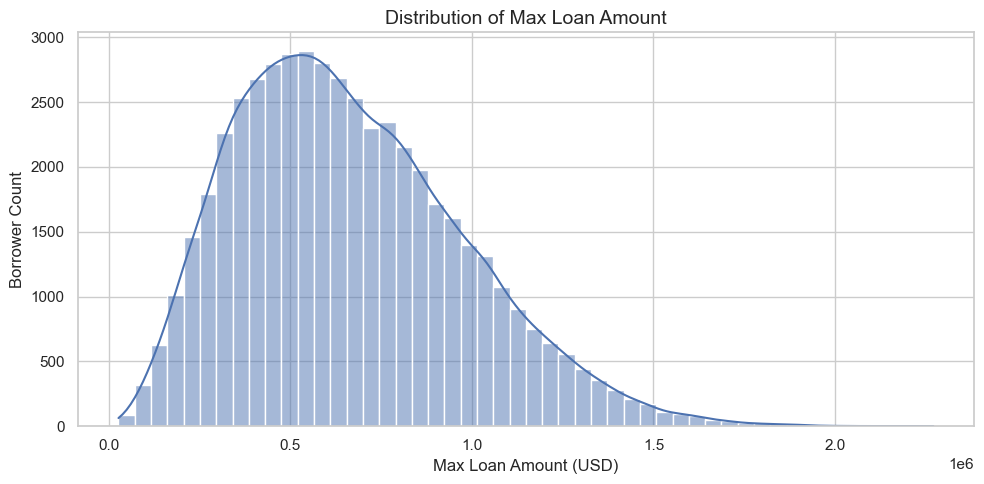

In [11]:
# Target variable distribution
plt.figure(figsize=(10, 5))
sns.histplot(df[target], bins=50, kde=True)
plt.title("Distribution of Max Loan Amount", fontsize=14)
plt.xlabel("Max Loan Amount (USD)")
plt.ylabel("Borrower Count")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_target_distribution.png", dpi=300)
plt.show()

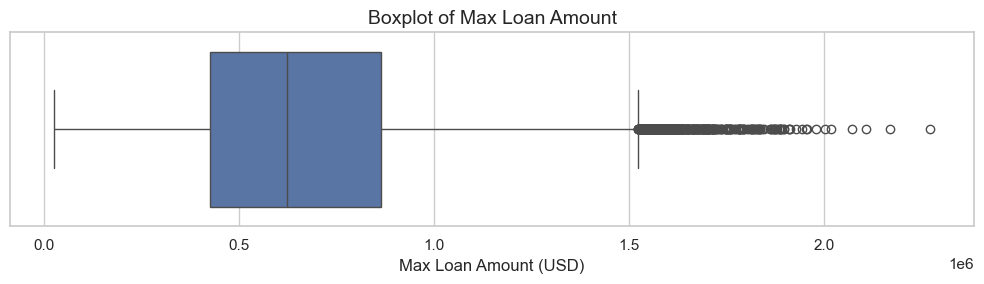

In [12]:
# Target variable boxplot
plt.figure(figsize=(10, 3))
sns.boxplot(x=df[target])
plt.title("Boxplot of Max Loan Amount", fontsize=14)
plt.xlabel("Max Loan Amount (USD)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_target_boxplot.png", dpi=300)
plt.show()

In [14]:
# Key statistics for target variable
target_summary = df[target].describe()
print("Target Variable Summary:")
print(target_summary)
print(f"\nMedian max loan amount: ${df[target].median():,.2f}")
print(f"Mean max loan amount: ${df[target].mean():,.2f}")
print(f"Minimum max loan amount: ${df[target].min():,.2f}")
print(f"Maximum max loan amount: ${df[target].max():,.2f}")

Target Variable Summary:
count      49,990.00
mean      663,419.15
std       312,681.14
min        26,142.54
25%       425,422.80
50%       623,243.47
75%       864,104.89
max     2,270,835.80
Name: Max Loan Amount (USD), dtype: float64

Median max loan amount: $623,243.47
Mean max loan amount: $663,419.15
Minimum max loan amount: $26,142.54
Maximum max loan amount: $2,270,835.80


## Numerical Feature Analysis

This section explores the numerical variables that may influence maximum mortgage loan amount.

Important numerical features, identified from the previous screening, include:

- Age
- Employment Years
- Annual Income
- Interest Rate
- Down Payment
- Credit Score
- Existing Monthly Debt
- Loans Repaid

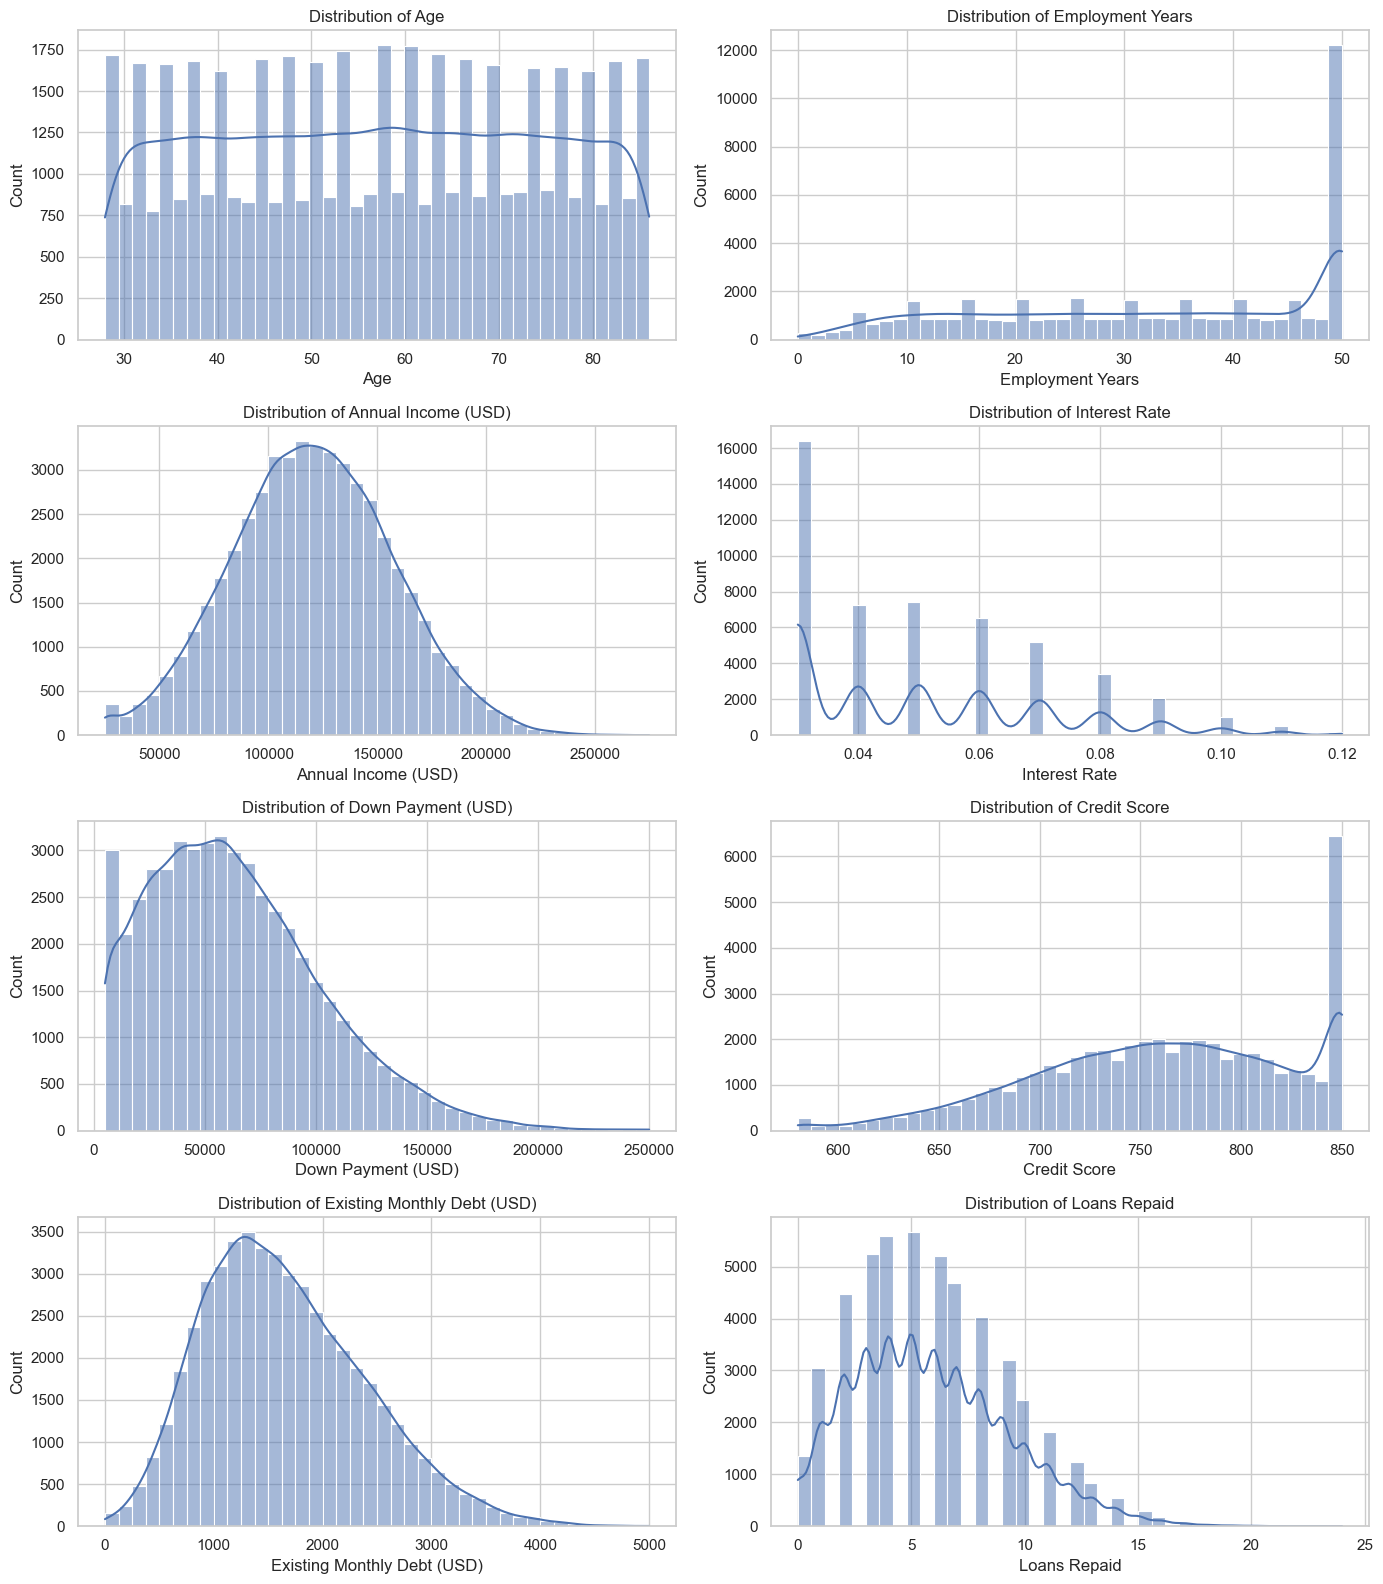

In [15]:
# Numerical feature distributions

num_features = [
    "Age",
    "Employment Years",
    "Annual Income (USD)",
    "Interest Rate",
    "Down Payment (USD)",
    "Credit Score",
    "Existing Monthly Debt (USD)",
    "Loans Repaid"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, num_features):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_numerical_feature_distributions.png", dpi=300)
plt.show()

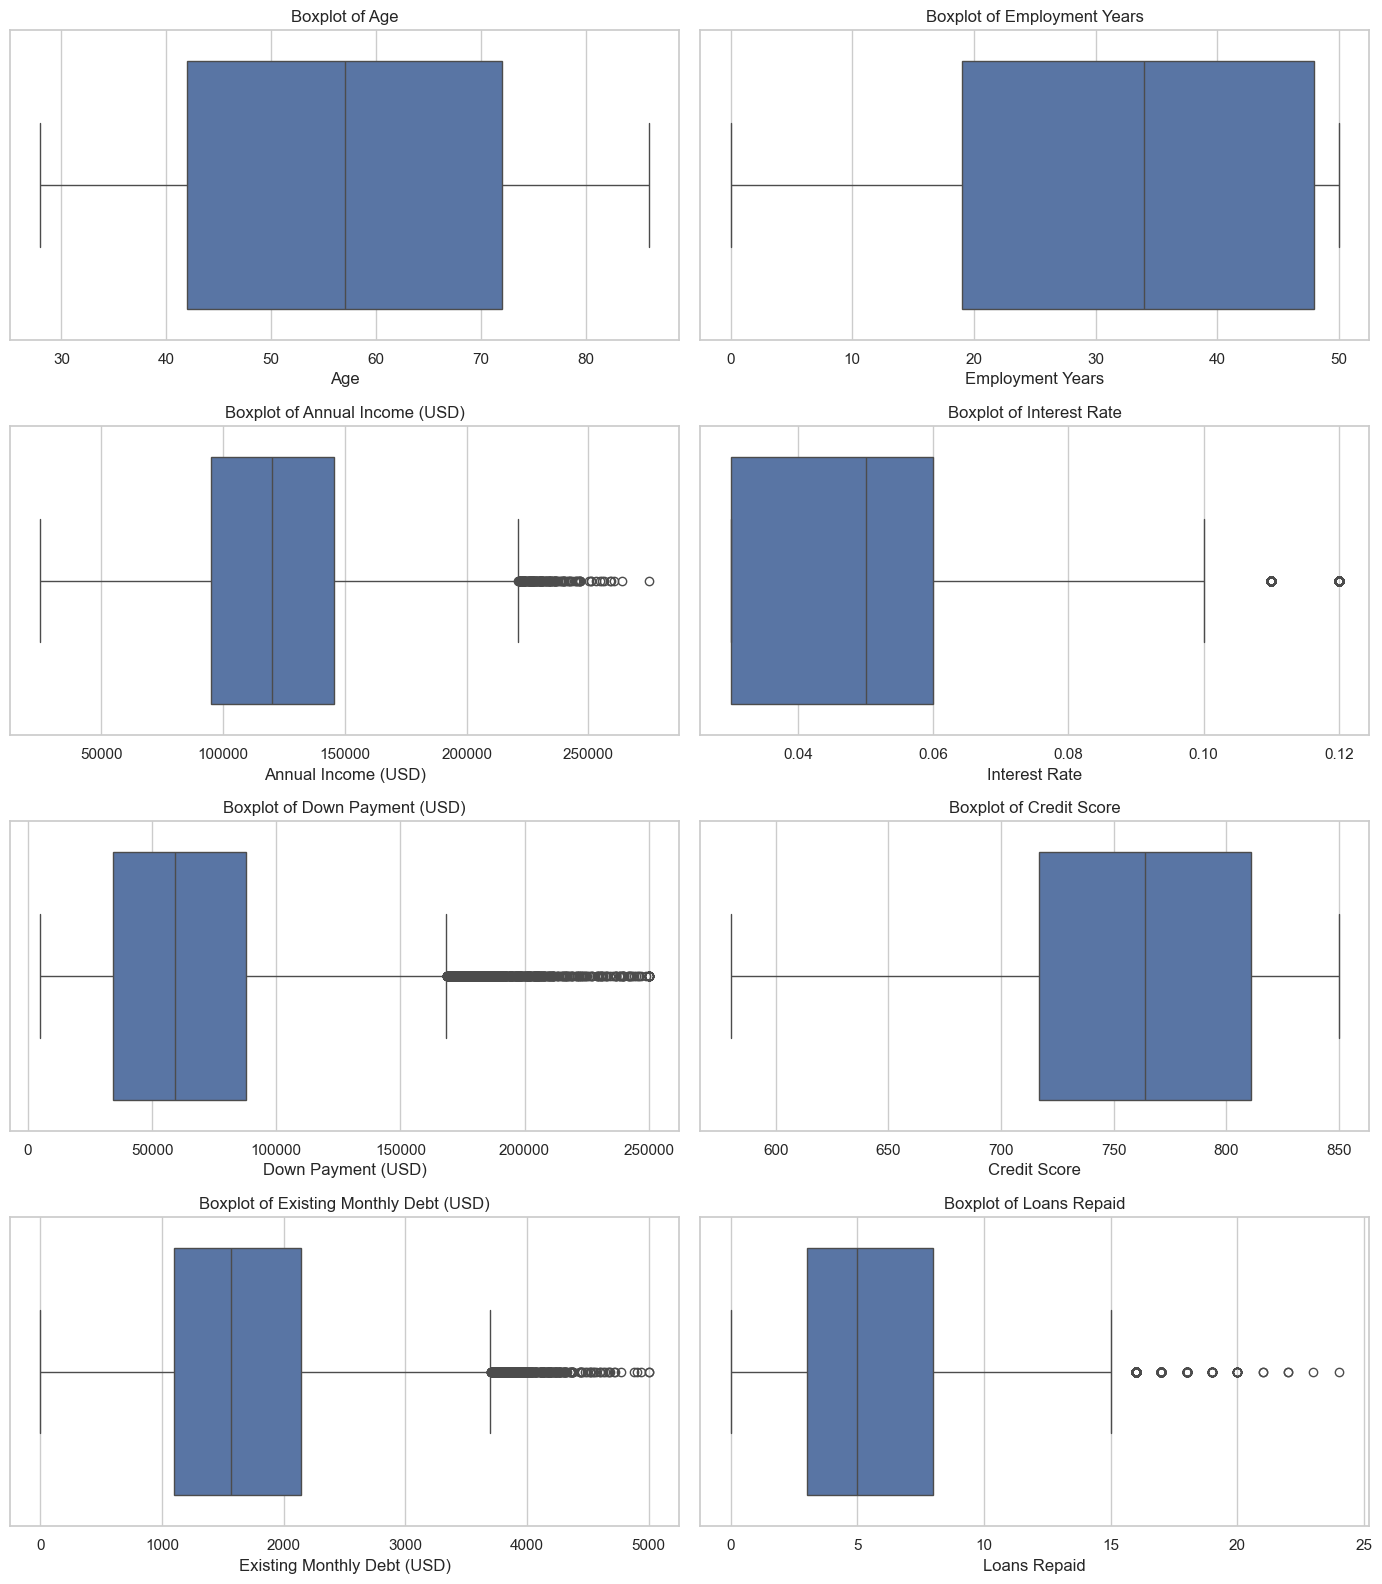

In [16]:
# Boxplots for numerical features

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, num_features):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_numerical_feature_boxplots.png", dpi=300)
plt.show()

## Relationship Between Numerical Features and Max Loan Amount

The section generates scatter plots to visualize how key financial and credit-related variables relate to the target variable.

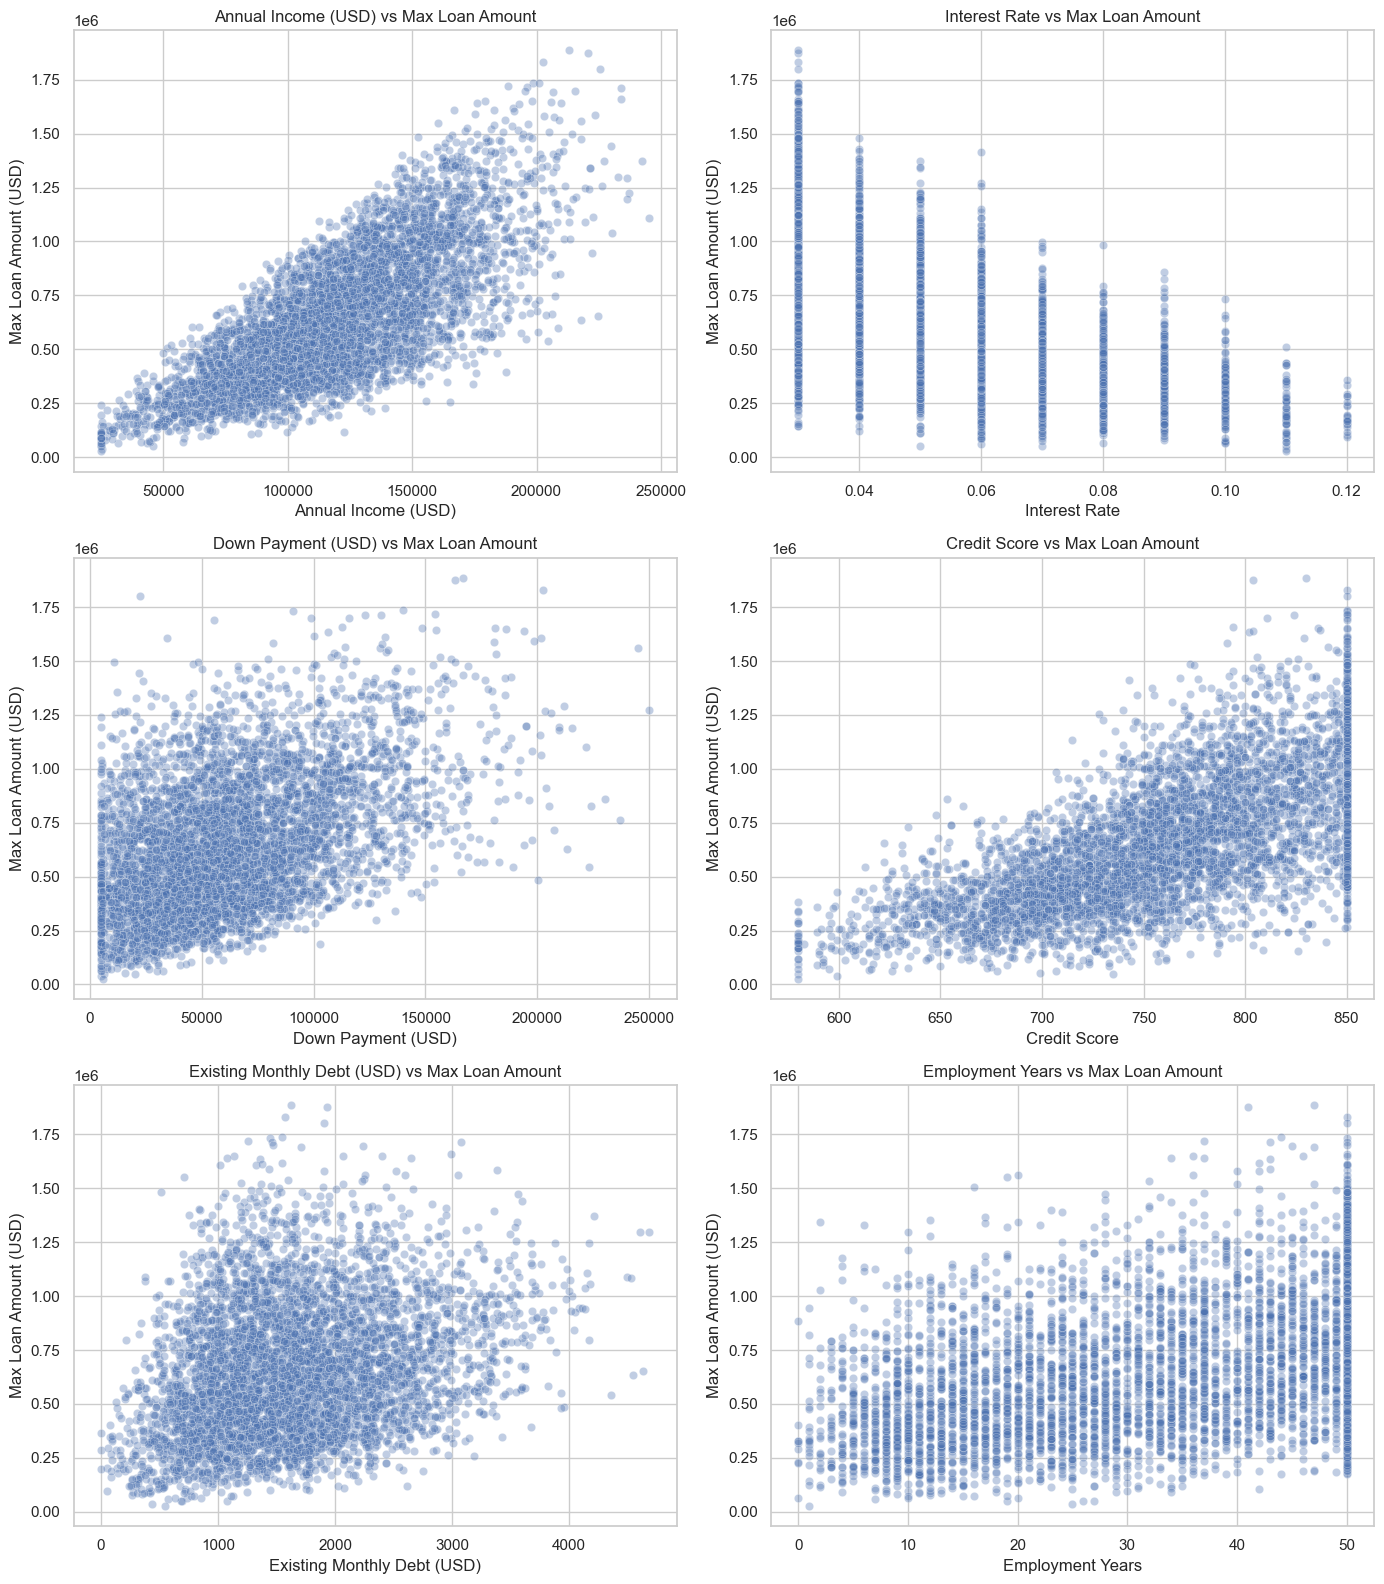

In [17]:
# Scatter plots of numerical features vs target

relationship_features = [
    "Annual Income (USD)",
    "Interest Rate",
    "Down Payment (USD)",
    "Credit Score",
    "Existing Monthly Debt (USD)",
    "Employment Years"
]
sample_df = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, relationship_features):
    sns.scatterplot(
        data=sample_df,
        x=col,
        y=target,
        alpha=0.35,
        ax=ax
    )
    ax.set_title(f"{col} vs Max Loan Amount")
    ax.set_xlabel(col)
    ax.set_ylabel("Max Loan Amount (USD)")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_numerical_relationships_vs_target.png", dpi=300)
plt.show()

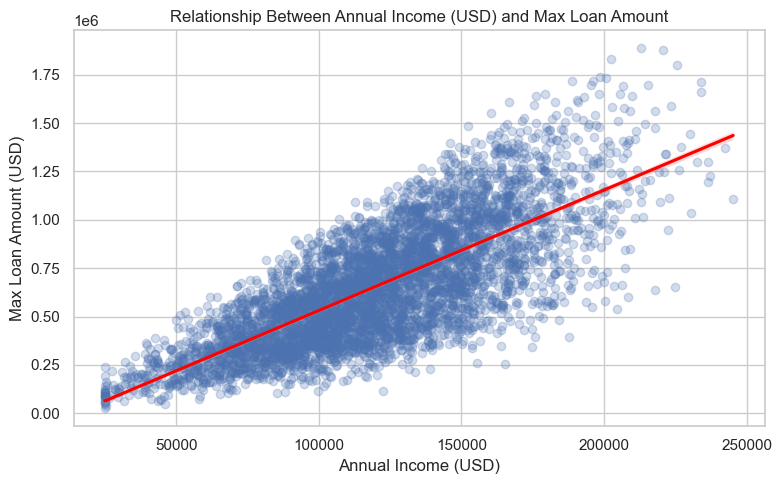

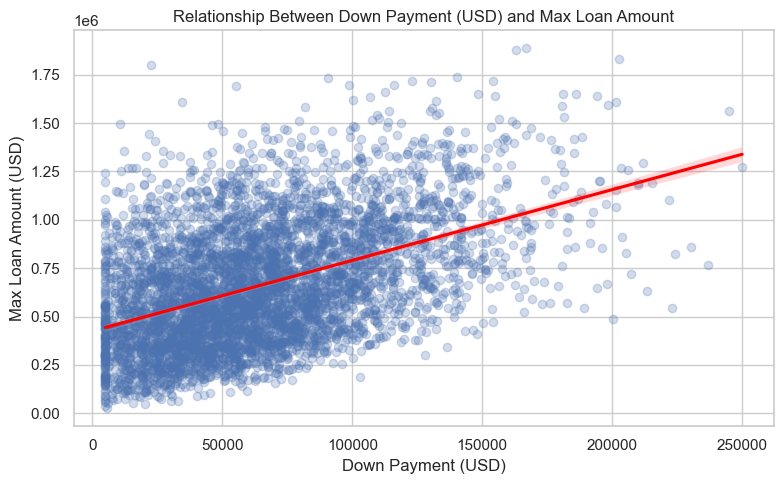

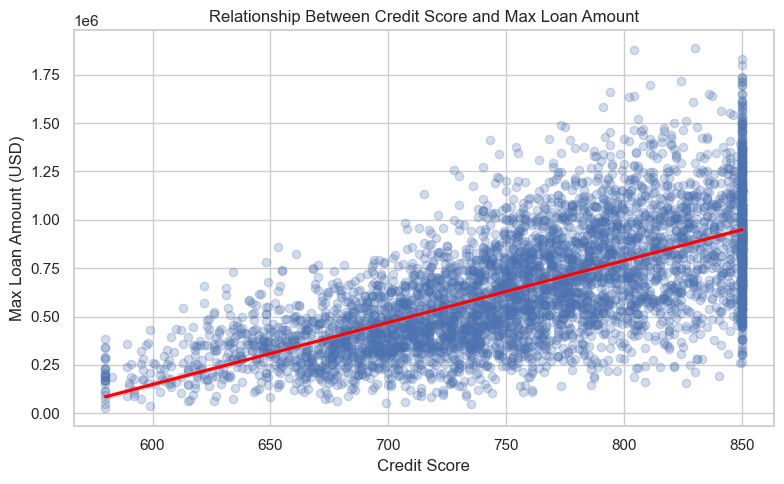

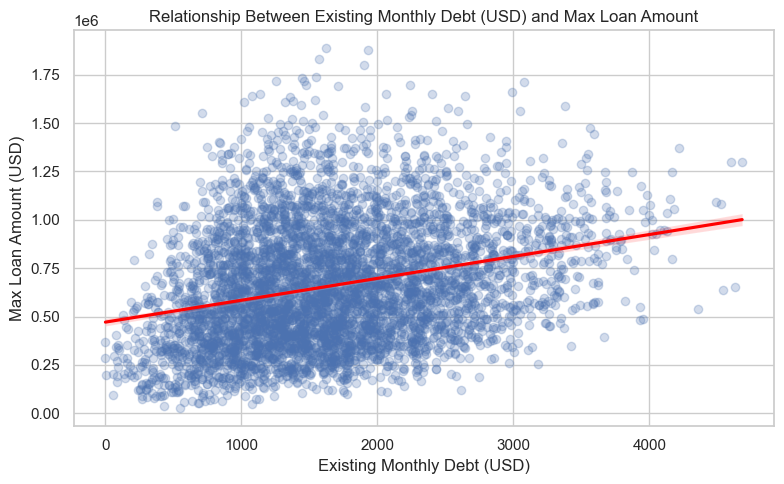

In [18]:
# Regression plots for the most important financial variables

important_financial_features = [
    "Annual Income (USD)",
    "Down Payment (USD)",
    "Credit Score",
    "Existing Monthly Debt (USD)"
]

for col in important_financial_features:
    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=sample_df,
        x=col,
        y=target,
        scatter_kws={"alpha": 0.25},
        line_kws={"color": "red"}
    )
    plt.title(f"Relationship Between {col} and Max Loan Amount")
    plt.xlabel(col)
    plt.ylabel("Max Loan Amount (USD)")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"relationship_{col.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.png", dpi=300)
    plt.show()

## Categorical Feature Analysis

This section explores categorical borrower characteristics.

Categorical variables include:

- Gender
- Married
- Education
- Job
- Area

The goal is to understand whether average or median maximum loan amount differs across borrower groups.

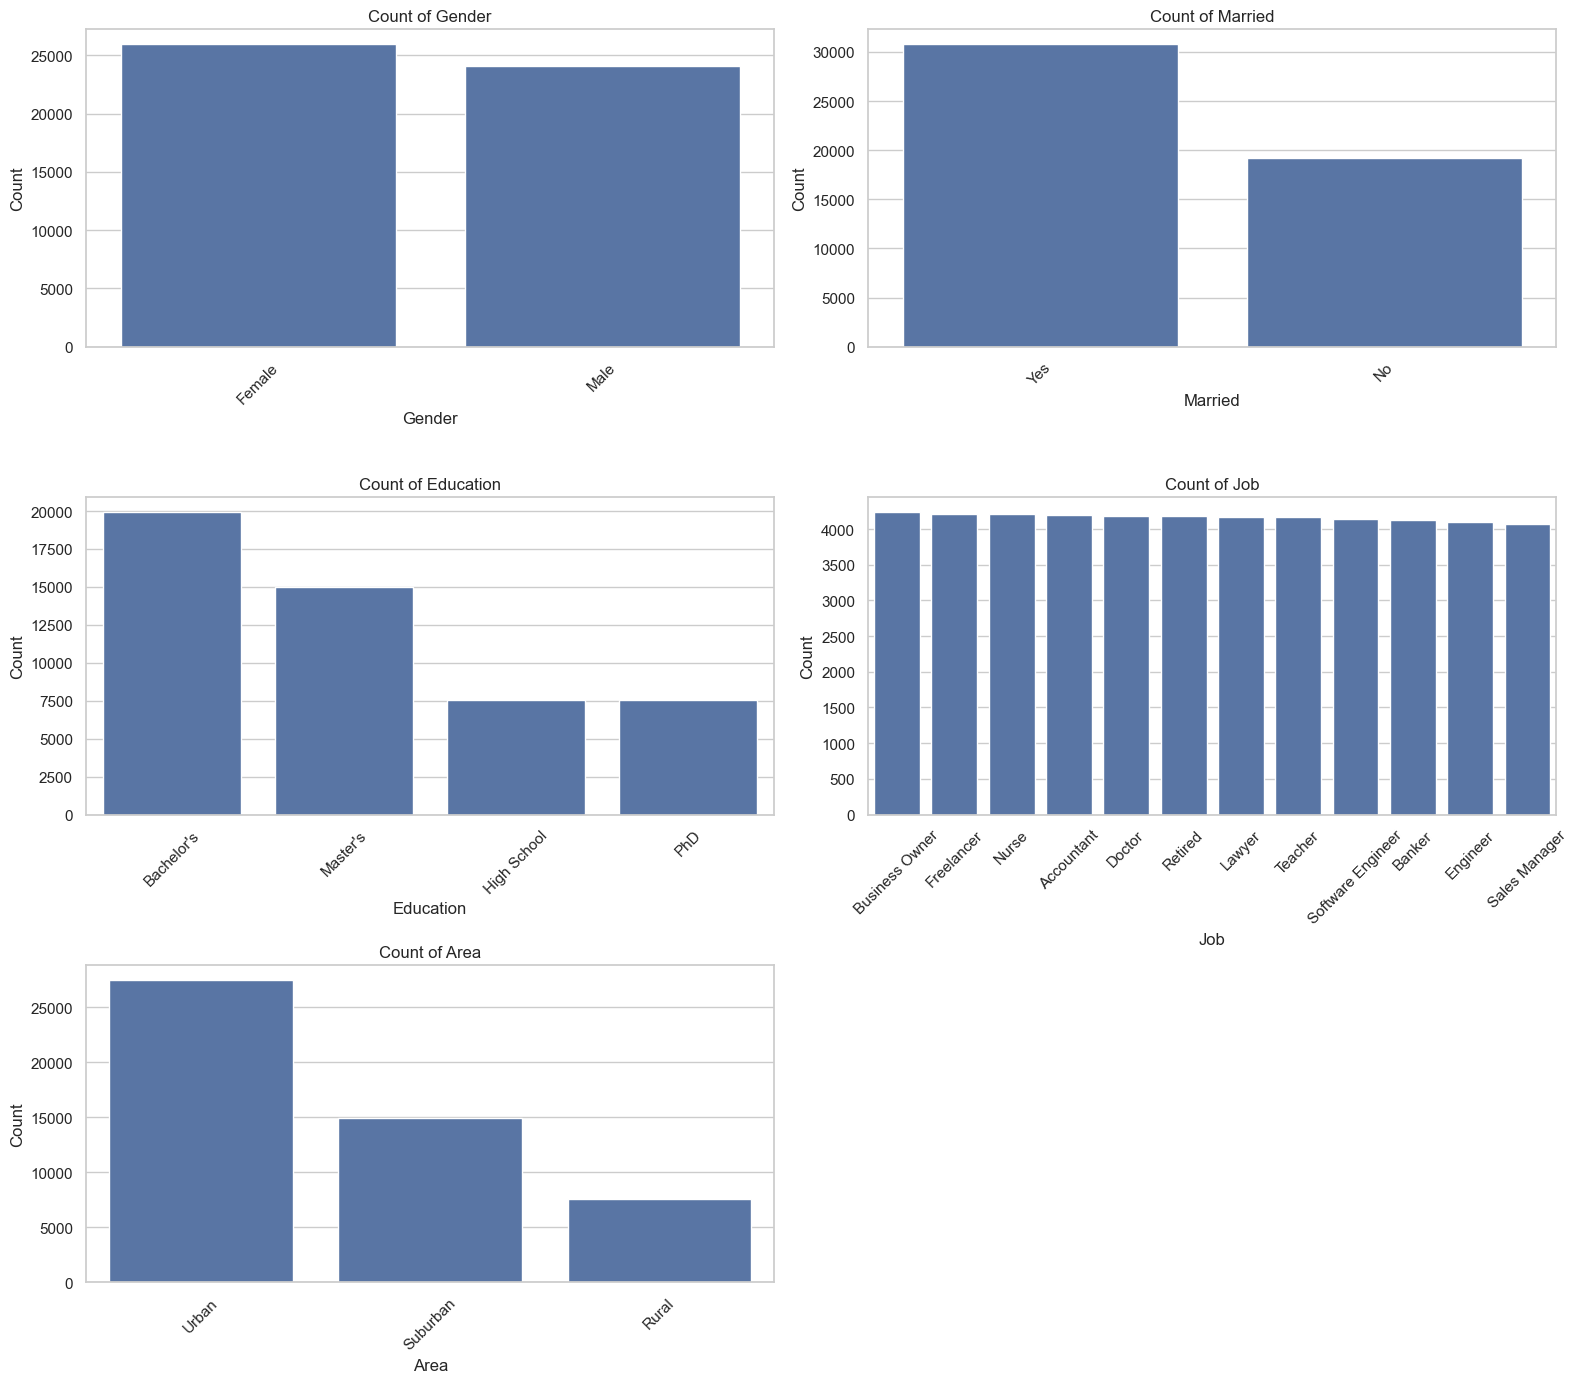

In [19]:
# Count plots for categorical features

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, categorical_columns):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f"Count of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for i in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_categorical_feature_counts.png", dpi=300)
plt.show()

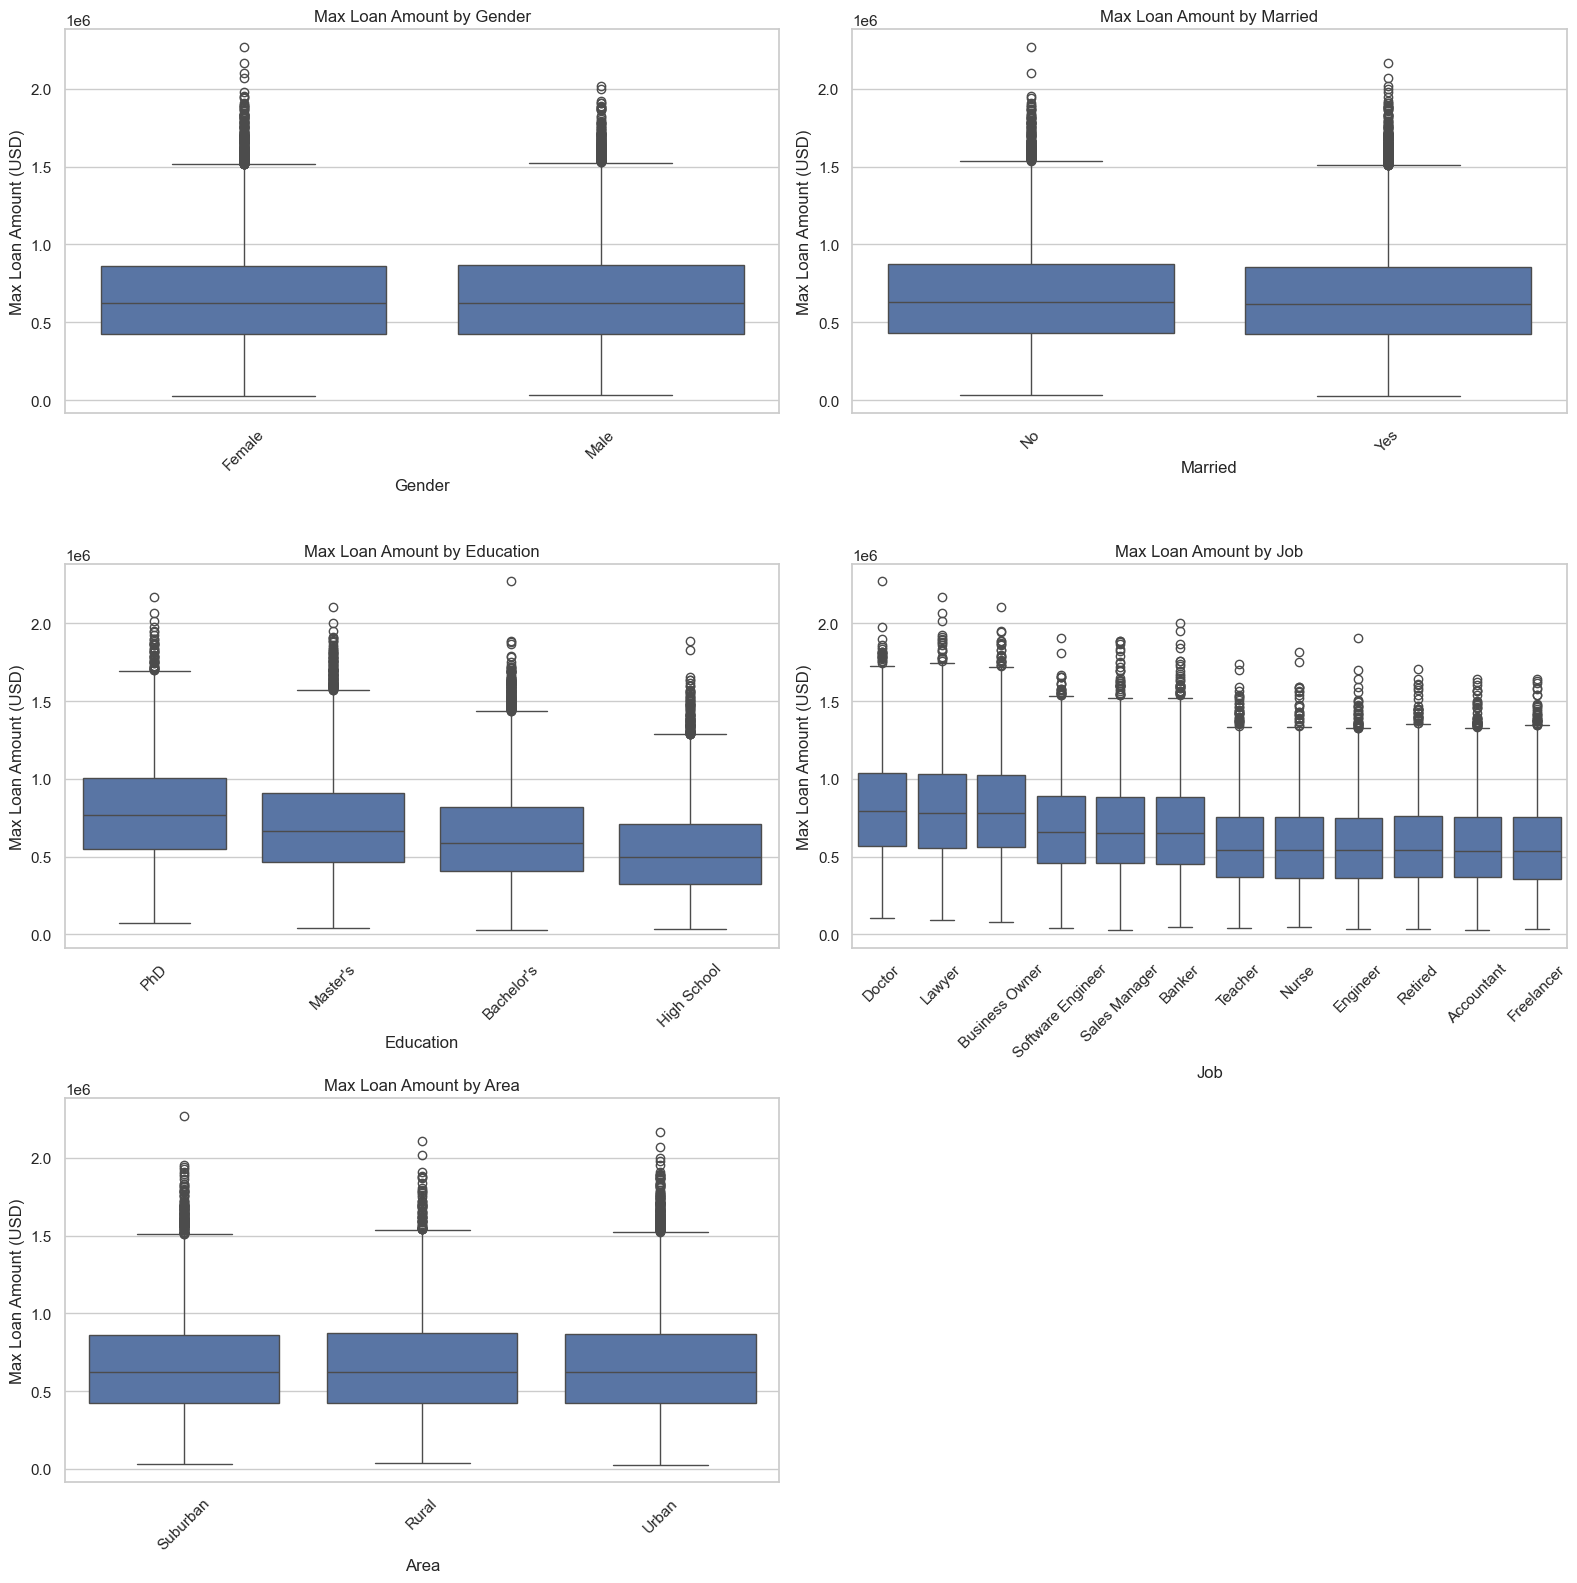

In [20]:
# Boxplots of categorical features vs target

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, col in zip(axes, categorical_columns):
    order = df.groupby(col)[target].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y=target, order=order, ax=ax)
    ax.set_title(f"Max Loan Amount by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Max Loan Amount (USD)")
    ax.tick_params(axis="x", rotation=45)

for i in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_categorical_features_vs_target.png", dpi=300)
plt.show()

In [21]:
# Average and median max loan amount by categorical group

for col in categorical_columns:
    print("=" * 80)
    print(f"Max Loan Amount Summary by {col}")
    print("=" * 80)
    
    display(
        df.groupby(col)[target]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )

Max Loan Amount Summary by Gender


,count,mean,median,std
Gender,,,,
Female,25938,"663,813.99","623,829.89","313,220.82"
Male,24052,"662,993.35","622,952.08","312,104.04"


Max Loan Amount Summary by Married


,count,mean,median,std
Married,,,,
No,19227,"670,690.57","632,221.13","315,852.13"
Yes,30763,"658,874.48","618,057.38","310,601.54"


Max Loan Amount Summary by Education


,count,mean,median,std
Education,,,,
PhD,7528,"790,977.45","769,189.30","325,794.64"
Master's,14969,"705,808.44","668,168.93","312,178.79"
Bachelor's,19920,"629,909.39","590,615.74","296,385.52"
High School,7573,"540,974.95","495,140.75","280,245.58"


Max Loan Amount Summary by Job


,count,mean,median,std
Job,,,,
Doctor,4180,"818,661.69","791,988.77","326,887.49"
Lawyer,4170,"809,328.99","782,799.26","327,419.73"
Business Owner,4235,"807,226.14","780,884.67","326,568.55"
Sales Manager,4069,"692,329.41","655,493.17","305,454.10"
Software Engineer,4145,"692,184.27","659,879.85","302,292.24"
Banker,4132,"686,367.61","649,431.39","302,646.16"
Retired,4177,"579,564.43","539,993.78","278,912.33"
Teacher,4163,"577,678.89","545,323.70","276,179.87"
Engineer,4094,"575,127.11","541,863.19","278,014.73"


Max Loan Amount Summary by Area


,count,mean,median,std
Area,,,,
Rural,7550,"665,522.87","623,743.76","313,565.85"
Urban,27466,"663,401.32","622,747.15","312,649.72"
Suburban,14974,"662,391.13","625,021.56","312,307.48"


## Feature Engineering for Exploratory Analysis

This SECTION creates several engineered features:

- **Debt to Income Ratio**: annualized debt divided by annual income
- **Available Annual Income**: annual income minus annual debt payments
- **Down Payment to Income Ratio**: down payment divided by annual income
- **Employment Stability Ratio**: employment years divided by age
- **Loan Repayment Rate**: loans repaid divided by employment years plus one

These features will be used in the 2_Modeling_Evaluation Notebook

In [22]:
# Create engineered features
df_engineered = df.copy()

df_engineered["Debt to Income Ratio"] = (
    df_engineered["Existing Monthly Debt (USD)"] * 12
) / df_engineered["Annual Income (USD)"]

df_engineered["Available Annual Income (USD)"] = (
    df_engineered["Annual Income (USD)"]
    - df_engineered["Existing Monthly Debt (USD)"] * 12
)

df_engineered["Down Payment to Income Ratio"] = (
    df_engineered["Down Payment (USD)"]
    / df_engineered["Annual Income (USD)"]
)

df_engineered["Employment Stability Ratio"] = (
    df_engineered["Employment Years"]
    / df_engineered["Age"]
)

df_engineered["Loan Repayment Rate"] = (
    df_engineered["Loans Repaid"]
    / (df_engineered["Employment Years"] + 1)
)

df_engineered["Credit Score Category"] = pd.cut(
    df_engineered["Credit Score"],
    bins=[299, 579, 669, 739, 799, 850],
    labels=["Poor", "Fair", "Good", "Very Good", "Excellent"]
)

df_engineered["Income Category"] = pd.qcut(
    df_engineered["Annual Income (USD)"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df_engineered.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD),Debt to Income Ratio,Available Annual Income (USD),Down Payment to Income Ratio,Employment Stability Ratio,Loan Repayment Rate,Credit Score Category,Income Category
0,Male,36,Yes,PhD,Software Engineer,13,"134,183.86",0.08,"101,706.78",682,"2,045.80",Urban,3,"498,842.67",0.18,"109,634.26",0.76,0.36,0.21,Good,High
1,Female,63,No,High School,Freelancer,37,"68,884.95",0.03,"46,324.29",823,804.73,Suburban,10,"536,232.53",0.14,"59,228.19",0.67,0.59,0.26,Excellent,Low
2,Female,33,Yes,PhD,Nurse,11,"76,396.27",0.03,"13,045.79",813,"1,050.54",Urban,0,"518,884.47",0.17,"63,789.79",0.17,0.33,0.00,Excellent,Low
3,Female,51,Yes,Bachelor's,Business Owner,29,"115,968.80",0.05,"60,388.40",752,904.08,Rural,2,"757,940.14",0.09,"105,119.84",0.52,0.57,0.07,Very Good,Medium
4,Male,53,Yes,Bachelor's,Nurse,27,"99,977.38",0.06,"54,838.14",728,"2,285.76",Rural,1,"283,110.21",0.27,"72,548.26",0.55,0.51,0.04,Good,Medium


In [23]:
# Check engineered feature summary
engineered_features = [
    "Debt to Income Ratio",
    "Available Annual Income (USD)",
    "Down Payment to Income Ratio",
    "Employment Stability Ratio",
    "Loan Repayment Rate"
]

df_engineered[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Debt to Income Ratio,"49,990.00",0.17,0.05,0.00,0.12,0.16,0.21,0.43
Available Annual Income (USD),"49,990.00","100,444.23","31,535.22","15,070.48","78,879.03","99,867.76","121,575.84","240,598.27"
Down Payment to Income Ratio,"49,990.00",0.54,0.28,0.02,0.33,0.53,0.73,2.17
Employment Stability Ratio,"49,990.00",0.53,0.15,0.00,0.45,0.58,0.63,0.77
Loan Repayment Rate,"49,990.00",0.20,0.17,0.00,0.12,0.17,0.24,8.00


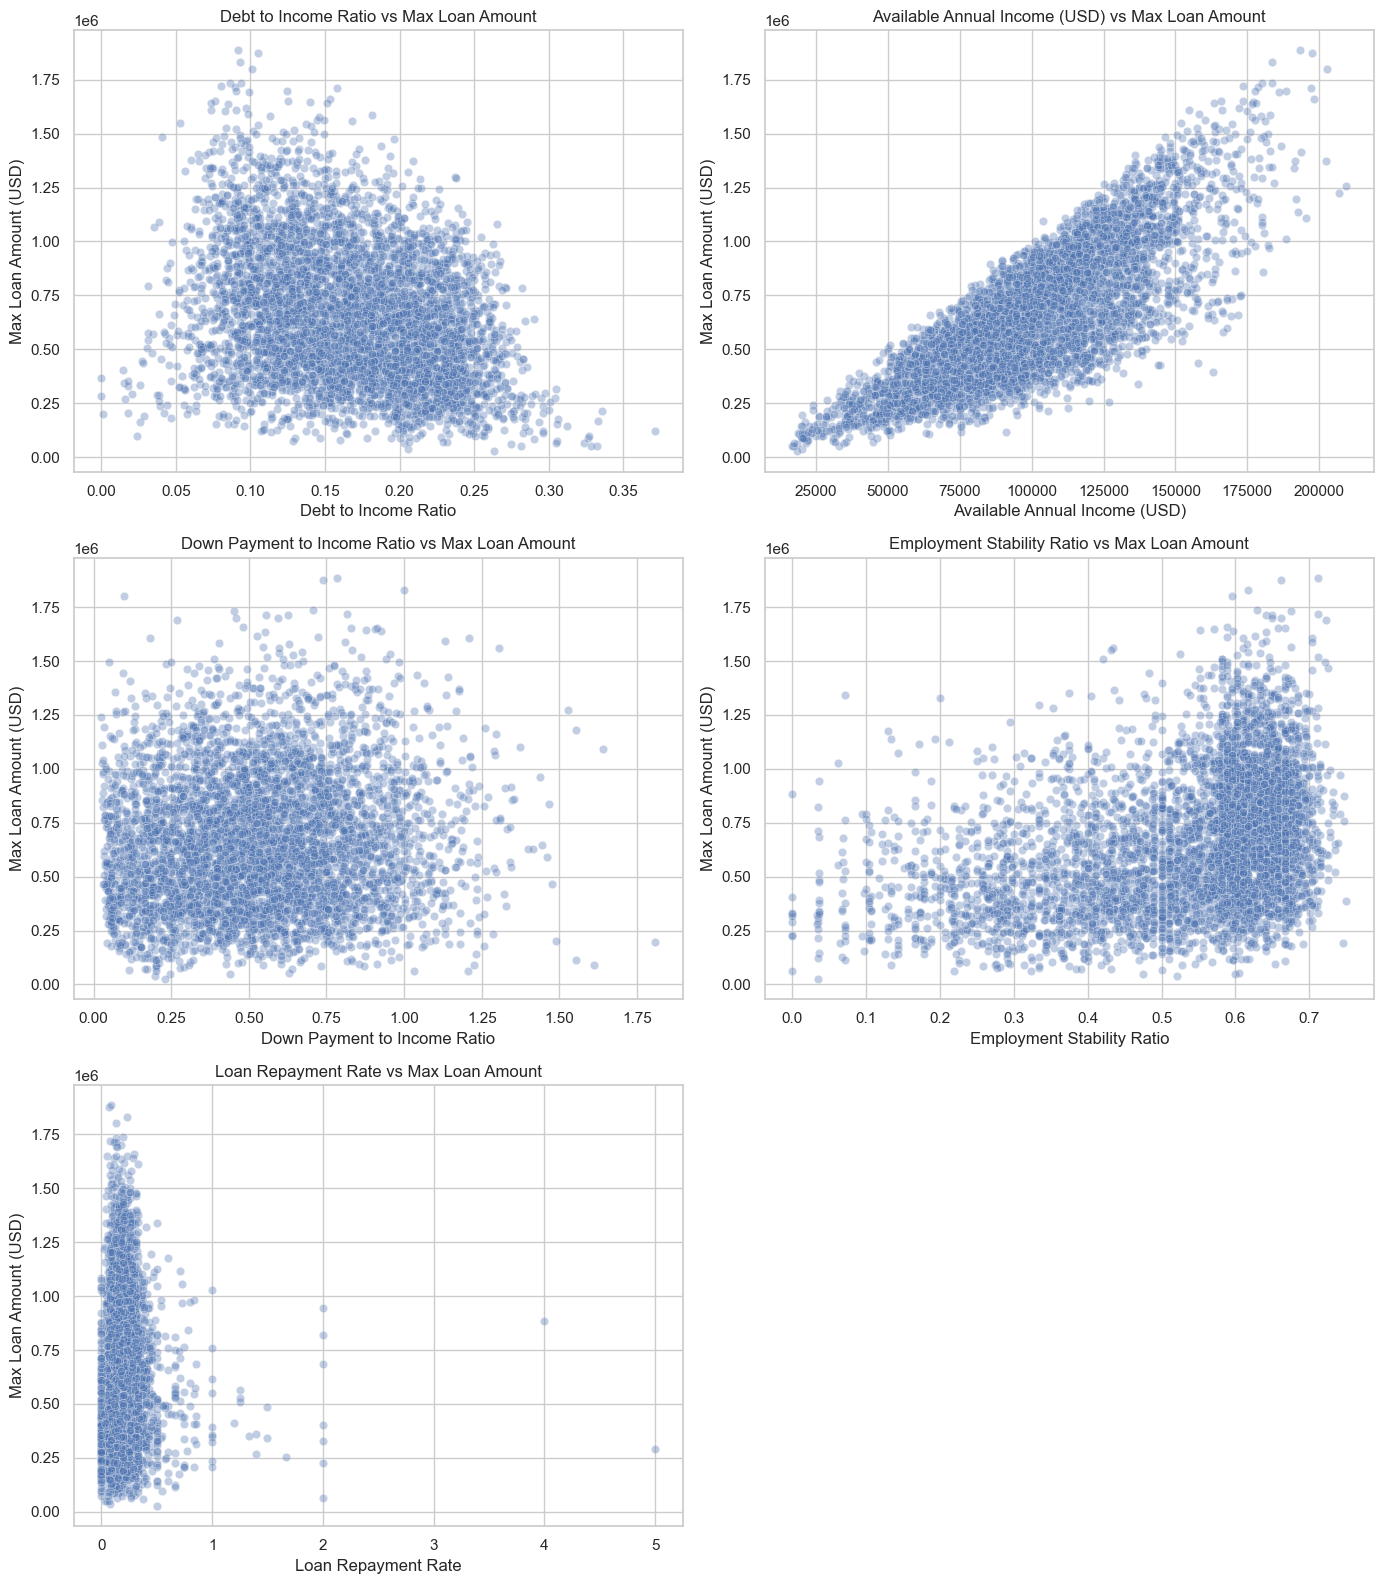

In [24]:
# Relationship between engineered features and target
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, engineered_features):
    sns.scatterplot(
        data=df_engineered.sample(n=min(5000, len(df_engineered)), random_state=RANDOM_STATE),
        x=col,
        y=target,
        alpha=0.35,
        ax=ax
    )
    ax.set_title(f"{col} vs Max Loan Amount")
    ax.set_xlabel(col)
    ax.set_ylabel("Max Loan Amount (USD)")

# Remove unused subplot
for i in range(len(engineered_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_engineered_features_vs_target.png", dpi=300)
plt.show()

## Correlation Analysis

This section focuses on the indenifition of which numerical variables have the strongest linear relationship with maximum loan amount.

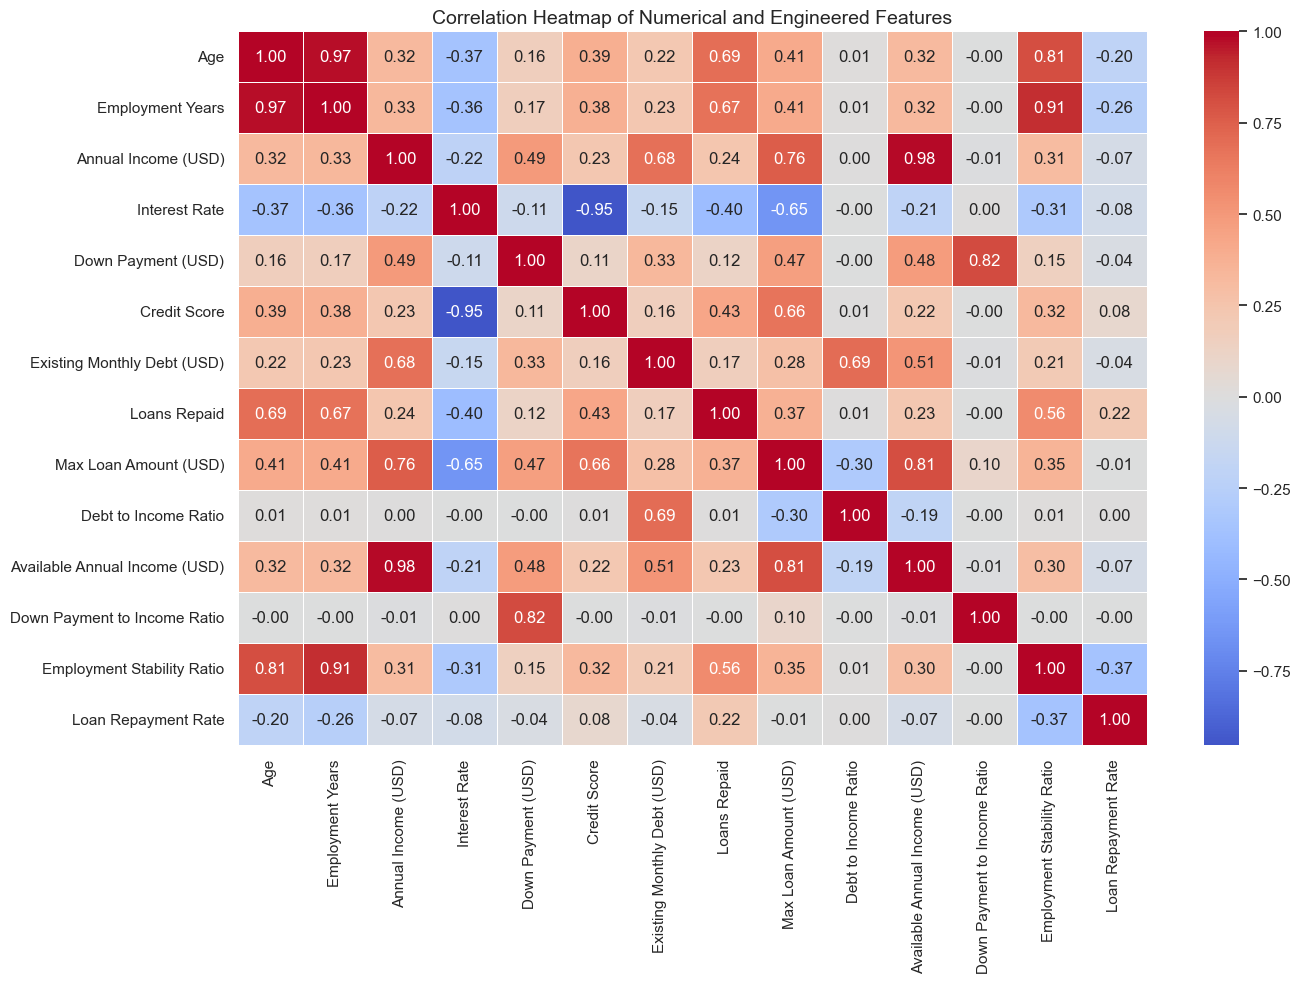

In [25]:
# Correlation heatmap with original and engineered numerical features

correlation_columns = df_engineered.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df_engineered[correlation_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical and Engineered Features", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_correlation_heatmap_engineered.png", dpi=300)
plt.show()

In [26]:
# Correlation of each numerical variable with target

target_correlations = (
    df_engineered[correlation_columns]
    .corr()[target]
    .sort_values(ascending=False)
)

target_correlations_df = pd.DataFrame({
    "Feature": target_correlations.index,
    "Correlation with Max Loan Amount": target_correlations.values
})

target_correlations_df

,Feature,Correlation with Max Loan Amount
0,Max Loan Amount (USD),1.00
1,Available Annual Income (USD),0.81
2,Annual Income (USD),0.76
3,Credit Score,0.66
4,Down Payment (USD),0.47
5,Employment Years,0.41
6,Age,0.41
7,Loans Repaid,0.37
8,Employment Stability Ratio,0.35
9,Existing Monthly Debt (USD),0.28


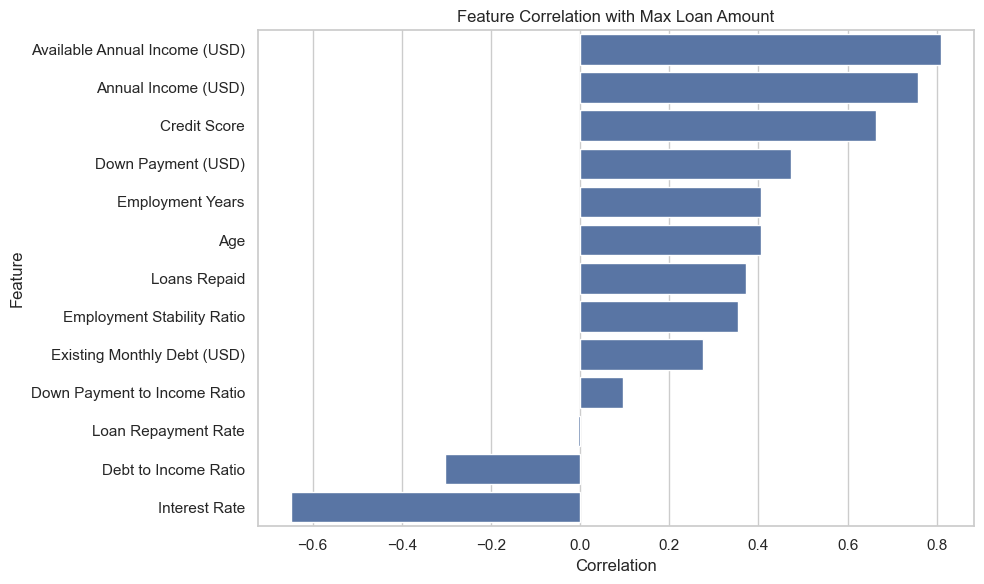

In [27]:
# Bar plot of correlations with target
plot_corr_df = target_correlations_df[target_correlations_df["Feature"] != target]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_corr_df,
    x="Correlation with Max Loan Amount",
    y="Feature"
)
plt.title("Feature Correlation with Max Loan Amount")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "10_feature_target_correlations.png", dpi=300)
plt.show()

## Initial EDA Findings

Based on the exploratory analysis, the following variables are expected to be important for predicting maximum mortgage loan amount:

1. **Annual Income**  
   Higher annual income should increase borrowing capacity.

2. **Down Payment**  
   Larger down payments reduce lender risk and may support higher loan amounts.

3. **Credit Score**  
   Higher credit scores generally indicate stronger borrower credit quality.

4. **Existing Monthly Debt**  
   Higher existing debt may reduce available borrowing capacity.

5. **Interest Rate**  
   Higher interest rates may reduce maximum affordable loan amount.

6. **Debt to Income Ratio**  
   This engineered feature captures debt burden relative to income.

7. **Available Annual Income**  
   This engineered feature estimates remaining income after annualized monthly debt payments.

In [29]:
processed_file_path = PROCESSED_DIR / "mortgage_loan_dataset_engineered.csv"
df_engineered.to_csv(processed_file_path, index=False)
print(f"Engineered dataset saved to: {processed_file_path}")
print(f"Rows: {df_engineered.shape[0]:,}")
print(f"Columns: {df_engineered.shape[1]:,}")

Engineered dataset saved to: outputs/processed_data/mortgage_loan_dataset_engineered.csv
Rows: 49,990
Columns: 21


In [30]:
# Save EDA summary tables
summary_output_path = OUTPUT_DIR / "eda_summary_tables"
summary_output_path.mkdir(parents=True, exist_ok=True)
missing_values_df.to_csv(summary_output_path / "missing_values_summary.csv")
# Target correlations
target_correlations_df.to_csv(summary_output_path / "target_correlations.csv", index=False)
# Category summaries
for col in categorical_columns:
    category_summary = (
        df.groupby(col)[target]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )
    category_summary.to_csv(summary_output_path / f"{col}_target_summary.csv")
print(f"EDA summary tables saved to: {summary_output_path}")

EDA summary tables saved to: outputs/eda_summary_tables


## Summary

This notebook completed the exploratory data analysis stage of the project.

Completed tasks:

- Loaded and inspected the mortgage loan dataset
- Confirmed dataset dimensions and column types
- Checked missing values and duplicate records
- Explored the target variable distribution
- Analyzed numerical and categorical features
- Visualized relationships between borrower features and maximum loan amount
- Created lending-related engineered features
- Examined correlations with the target variable
- Saved an engineered dataset for modeling